In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print(tf.__version__)

2.19.0


In [77]:
observations=1000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs = np.column_stack((xs, zs))
print(inputs.shape)

(1000, 2)


In [78]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 7 * xs + -7 * zs - 3 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000, 1)


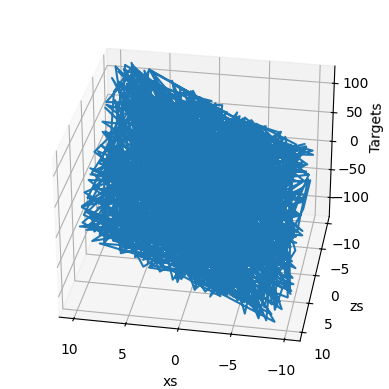

In [79]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [80]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights, biases)

[[-0.05768767]
 [ 0.03279491]] [-0.07967991]


In [81]:
targets = targets.reshape(observations,1) #ponowne przekształcenie
eta = 0.02
for i in range (100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

1569.7198672304992
219.51399740605655
33.611907344450366
7.905236439232559
4.244375279196145
3.6216472534546114
3.421639674157383
3.2843158656010827
3.159959878302011
3.041559535059182
2.9279850379751147
2.8189224697247397
2.7141764378744773
2.613573877929807
2.5169505794854055
2.424149103658511
2.335018276894938
2.2494129103564617
2.16719355869049
2.088226292232667
2.012382478755198
1.939538573921547
1.8695759200395283
1.8023805527758714
1.7378430155161808
1.6758581810676458
1.6163250804141265
1.5591467382445503
1.5042300149868715
1.4514854550901142
1.4008271413074593
1.3521725547429846
1.305442440434083
1.2605606782505785
1.2174541589003252
1.176052664839183
1.1362887558915007
1.0980976593947385
1.0614171646892432
1.026187521781405
0.9923513440150209
0.9598535145924249
0.9286410967929815
0.8986632477428725
0.8698711355955403
0.8422178599879665
0.8156583756432547
0.7901494189949589
0.765649437713725
0.742118523021421
0.7195183446824781
0.6978120885666046
0.676964396681092
0.6569413095

In [82]:
print(weights, biases)

[[ 6.99957895]
 [-6.99930659]] [-2.62853131]


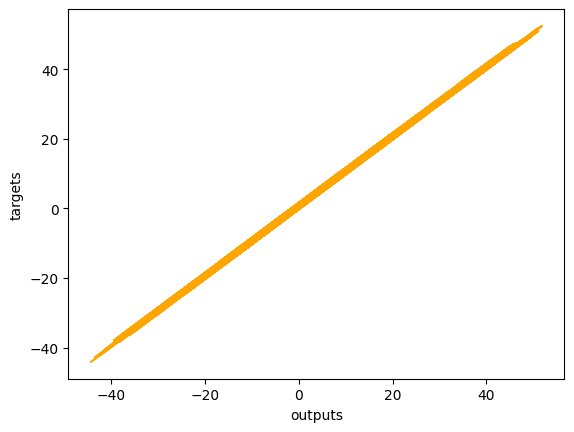

In [35]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

### Zadanie 1:
Wagi oraz bias przy ilości próbek = 1000:

Cel: [[2] [-3]] [5]

Wynik: [[ 2.00345413] [-2.99790256]] [4.34168587]

‎
‎

Wagi oraz bias przy ilości próbek = 1000000:

Cel: [[2] [-3]] [5]

Wynik: [[ 2.00018563] [-3.00004665]] [4.33006943]

‎
‎

---

‎
‎

### Zadanie 2:
(Wykonane dla ilości próbek = 1000)

Wagi oraz bias po zmianie współczynnika uczenia się eta na:

a. 0.0001:

Cel: [[2] [-3]] [5]

Wynik: [[ 0.56656894] [-0.81967521]] [0.08846841]

‎
‎

b. 0.001:

Cel: [[2] [-3]] [5]

Wynik: [[ 1.90920638] [-2.89010028]] [0.43195702]

‎
‎

c. 0.1:

Cel: [[2] [-3]] [5]

Wynik: [[5.72025890e+38] [2.45153826e+39]] [-5.26661033e+36]

‎
‎

d. 1:

Cel: [[2] [-3]] [5]

Wynik: [[-2.25800166e+152] [8.90397860e+150]] [5.46849083e+149]

‎
‎

---

‎
‎

### Zadanie 3:
Zmiana targets na 13 * xs + 7 * zs - 12 (ilość próbek = 1000, eta = 0.02)

Cel: [[13] [7]] [-12]

Wynik: [[13.00840642] [7.01246193]] [-10.43017297]

‎
‎

Zmiana targets na 5 * xs + 10 * zs - 15 (ilość próbek = 1000, eta = 0.02)

Cel: [[5] [10]] [-15]

Wynik: [[4.98867322] [10.0045709]] [-12.99440407]

‎
‎

Zmiana targets na 7 * xs + -7 * zs - 3 (ilość próbek = 1000, eta = 0.02)

Cel: [[7] [-7]] [-3]

Wynik: [[6.99957895] [-6.99930659]] [-2.62853131]